<a href="https://colab.research.google.com/github/ranjankumar22062/Deeplearning-projects/blob/main/DL_Project_3_Dog_vs_Cat_Classification_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#kaggle api
!kaggle competitions download -c dogs-vs-cats

dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
#extracting the compress file
from zipfile  import ZipFile

dataset = '/content/dogs-vs-cats.zip'
with ZipFile(dataset, 'r')as zip:
  zip.extractall()
  print("the dataset is extracted")

the dataset is extracted


In [ ]:
from zipfile  import ZipFile

dataset = '/content/train.zip'
with ZipFile(dataset, 'r')as zip:
  zip.extractall()
  print("the dataset is extracted")

the dataset is extracted


In [ ]:
import os
#counting the number of files in train folder
path,dirs,files =next(os.walk('/content/train'))
file_count =len(files)
print('Number of image: ',file_count)

Number of image:  25000


In [ ]:
file_names =os.listdir('/content/train/')
print(file_names)

['dog.7476.jpg', 'cat.4386.jpg', 'dog.180.jpg', 'dog.11327.jpg', 'cat.1337.jpg', 'dog.7978.jpg', 'cat.8383.jpg', 'dog.7666.jpg', 'dog.9250.jpg', 'cat.11304.jpg', 'dog.9829.jpg', 'dog.12128.jpg', 'cat.8606.jpg', 'dog.1662.jpg', 'cat.9989.jpg', 'cat.2591.jpg', 'dog.7960.jpg', 'dog.4561.jpg', 'dog.5878.jpg', 'dog.4755.jpg', 'cat.4151.jpg', 'dog.3738.jpg', 'cat.2128.jpg', 'dog.6746.jpg', 'dog.479.jpg', 'dog.8692.jpg', 'dog.11814.jpg', 'dog.6844.jpg', 'dog.548.jpg', 'cat.6567.jpg', 'dog.11078.jpg', 'cat.6222.jpg', 'cat.8486.jpg', 'cat.7560.jpg', 'dog.2895.jpg', 'cat.8146.jpg', 'cat.8898.jpg', 'cat.12078.jpg', 'cat.12183.jpg', 'dog.1204.jpg', 'cat.1738.jpg', 'dog.5658.jpg', 'cat.5509.jpg', 'dog.1734.jpg', 'cat.11425.jpg', 'dog.11342.jpg', 'cat.2648.jpg', 'cat.9994.jpg', 'dog.5609.jpg', 'dog.7566.jpg', 'dog.7989.jpg', 'cat.1077.jpg', 'dog.1091.jpg', 'cat.6509.jpg', 'cat.389.jpg', 'cat.4812.jpg', 'cat.11668.jpg', 'dog.2114.jpg', 'dog.3827.jpg', 'cat.923.jpg', 'cat.6774.jpg', 'cat.10423.jpg', '

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as Plt
import matplotlib.image as mping
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow


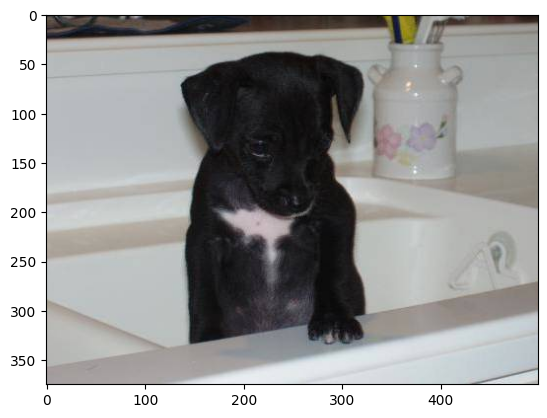

In [ ]:
#displaying dog image
img = mping.imread("/content/train/dog.8298.jpg")
imgplt= Plt.imshow(img)
Plt.show()

In [ ]:
file_names = os.listdir('/content/train/')

for i in range(5):

  name =file_names[i]
  print(name[0:3])

dog
cat
dog
dog
cat


In [ ]:
file_names = os.listdir('/content/train/')

dog_count= 0
cat_count=0
for img_file in file_names:
  name = img_file[0:3]
  if name =='dog':
    dog_count +=1
  else:
    cat_count += 1
print('Number of dog images=',dog_count)
print('Number of cat images=',cat_count)

Number of dog images= 12500
Number of cat images= 12500


Resizing all the image

In [ ]:
#creating a directory for resized images
os.mkdir('/content/images resized')

In [ ]:
original_folder='/content/train/'
resized_folder = '/content/images resized/'

for i in range(2000):
  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename


  img = Image.open(img_path)
  img= img.resize((128,128))
  img= img.convert('RGB')

  newImgpath = resized_folder+filename
  img.save(newImgpath)


Creating labels for resized images of dog and cats
  

  cat-> 0

  
  dog->1

In [ ]:
filenames= os.listdir('/content/images resized')

labels = [1 if filename.startswith('dog') else 0 for filename in filenames]

In [ ]:
print(filenames[0:5])

['dog.7476.jpg', 'cat.4386.jpg', 'dog.180.jpg', 'dog.11327.jpg', 'cat.1337.jpg']


In [ ]:
values,counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[1012  988]


Converting the all resized image to mumpy arrays


In [ ]:
import cv2
import glob

In [ ]:
image_directory = '/content/images resized/'
image_extension =['png','jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_image = np.asarray([cv2.imread(file) for file in files])

In [ ]:
print(dog_cat_image)

[[[[169 167 173]
   [169 167 173]
   [170 168 174]
   ...
   [232 230 236]
   [231 229 235]
   [230 228 234]]

  [[168 166 172]
   [169 167 173]
   [170 168 174]
   ...
   [231 229 235]
   [231 229 235]
   [230 228 234]]

  [[168 166 172]
   [169 167 173]
   [170 168 174]
   ...
   [231 229 235]
   [230 228 234]
   [229 227 233]]

  ...

  [[ 89  82  65]
   [113 108  93]
   [123 120 106]
   ...
   [229 228 232]
   [235 234 238]
   [217 216 220]]

  [[109 105  87]
   [132 127 112]
   [125 124 110]
   ...
   [253 252 255]
   [248 247 251]
   [225 224 228]]

  [[160 156 138]
   [151 148 133]
   [113 112  98]
   ...
   [247 246 250]
   [238 237 241]
   [238 237 241]]]


 [[[ 19  54 104]
   [ 21  56 106]
   [ 25  60 110]
   ...
   [  8  44  90]
   [  7  43  89]
   [  7  43  89]]

  [[ 16  51 101]
   [ 18  53 103]
   [ 21  56 106]
   ...
   [ 11  47  93]
   [ 11  47  93]
   [ 10  46  92]]

  [[ 17  53 101]
   [ 19  55 103]
   [ 21  57 105]
   ...
   [ 14  50  96]
   [ 13  49  95]
   [ 13  49

In [ ]:
print(dog_cat_image.shape)

(2000, 128, 128, 3)


In [ ]:
X = dog_cat_image
Y = np.asarray(labels)

In [ ]:
#train test split
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.2 ,random_state=2)

In [ ]:
print(X.shape)

(2000, 128, 128, 3)


In [ ]:
print(X_train.shape)

(1600, 128, 128, 3)


In [ ]:
#scalling the data
X_train_scaled=X_train/255
X_test_scaled = X_test/255

Building the neural network

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub

In [ ]:
mobilenet_model ='https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/035-128-classification/2'
pretrained_model = hub.KerasLayer(mobilenet_model,input_shape=(128,128,3),trainable=False)

In [ ]:
!pip install tf_keras
import tf_keras

In [ ]:
num_of_classes = 2

model = tf_keras.Sequential([

    pretrained_model,
    tf_keras.layers.Dense(num_of_classes)

])

model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1001)              1692489   
                                                                 
 dense_4 (Dense)             (None, 2)                 2004      
                                                                 
Total params: 1694493 (6.46 MB)
Trainable params: 2004 (7.83 KB)
Non-trainable params: 1692489 (6.46 MB)
_________________________________________________________________


In [ ]:
model.compile(

              optimizer ='adam',
              loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics =['acc']
)

In [ ]:
model.fit(X_train_scaled,Y_train,epochs=10)

Epoch 1/10
50/50 [==============================] - 7s 135ms/step - loss: 0.0872 - acc: 0.9719
Epoch 2/10
50/50 [==============================] - 5s 104ms/step - loss: 0.0853 - acc: 0.9725
Epoch 3/10
50/50 [==============================] - 6s 124ms/step - loss: 0.0848 - acc: 0.9700
Epoch 4/10
50/50 [==============================] - 5s 98ms/step - loss: 0.0767 - acc: 0.9744
Epoch 5/10
50/50 [==============================] - 6s 128ms/step - loss: 0.0858 - acc: 0.9669
Epoch 6/10
50/50 [==============================] - 5s 98ms/step - loss: 0.0813 - acc: 0.9688
Epoch 7/10
50/50 [==============================] - 5s 105ms/step - loss: 0.0742 - acc: 0.9769
Epoch 8/10
50/50 [==============================] - 6s 118ms/step - loss: 0.0714 - acc: 0.9787
Epoch 9/10
50/50 [==============================] - 5s 97ms/step - loss: 0.0679 - acc: 0.9769
Epoch 10/10
50/50 [==============================] - 6s 129ms/step - loss: 0.0643 - acc: 0.9819


In [ ]:
score,acc = model.evaluate(X_test_scaled,Y_test)
print('Test Loss=',score)
print('test accuracy',acc)


13/13 [==============================] - 3s 99ms/step - loss: 0.2881 - acc: 0.9075
Test Loss= 0.288100004196167
test accuracy 0.9075000286102295


path of the image to be predicted:/content/dog.jpg


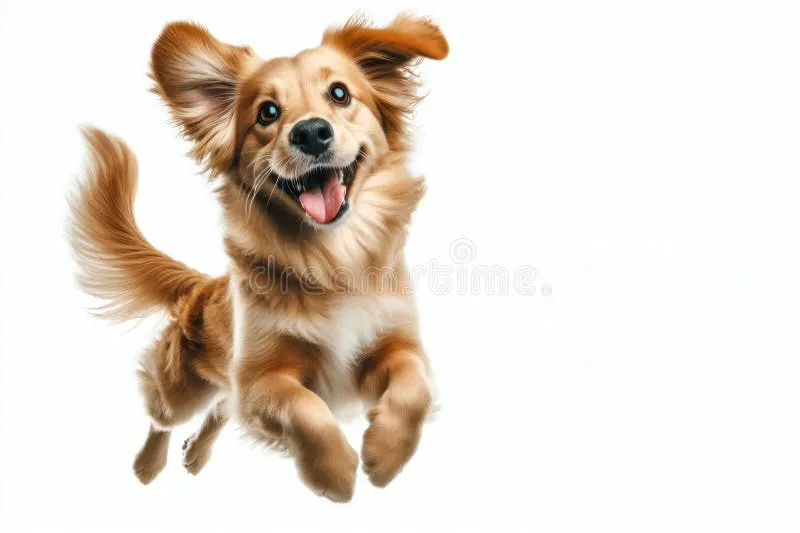

1/1 [==============================] - 0s 40ms/step
the image represent dog


In [ ]:
#predictive system
input_image_path= input('path of the image to be predicted:')

input_image= cv2.imread(input_image_path)

cv2_imshow(input_image)
input_images_resized=cv2.resize(input_image,(128,128))
input_image_scaled=input_images_resized/255

image_reshaped= np.reshape(input_image_scaled,[1,128,128,3])
input_prediction = model.predict(image_reshaped)
input_pred_label= np.argmax(input_prediction)

if input_pred_label==0:
  print('The image represent the cat')
else:
  print('the image represent dog')